<a href="https://colab.research.google.com/github/Anastetikc/Math_Stat/blob/main/%D0%9A%D0%BE%D0%BF%D0%B8%D1%8F_%D0%B1%D0%BB%D0%BE%D0%BA%D0%BD%D0%BE%D1%82%D0%B0_%222_normality_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sterolose/sirius-statistics-2026/blob/main/notebooks/2_normality.ipynb)

## Семинар 2. Статистическая оценка нормальности

В рамках этой работы научимся применять простейшие статистические тесты.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

Продолжим работать с "Palmer Penguins". Удалим пропущенные значения как раньше.

In [6]:
df = sns.load_dataset("penguins")
df = df.dropna()
df.head(2)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female


### Задание 1

При указании параметра `kde=True` для `sns.histplot` будет изображена эмпирическая плотность, оцененая по данным. Давайте сравним ее с теоретической плотностью нормального распределения с теми же средним и дисперсией для переменной `flipper_length_mm`.

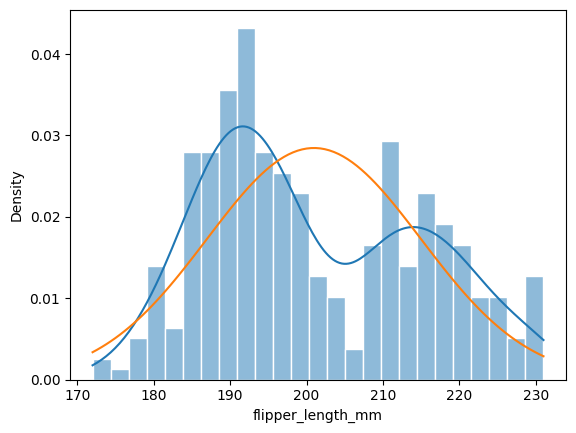

In [7]:
flipper = df["flipper_length_mm"]

sns.histplot(flipper, bins=25, stat="density", kde=True, alpha=0.5, edgecolor="white")

x = np.linspace(flipper.min(), flipper.max(), 100)
distr = stats.norm(flipper.mean(), flipper.std())
plt.plot(x, distr.pdf(x), color="tab:orange")

plt.show()

Повторите для той же переменной, но отдельно для каждого вида. Изобразите гистограммы и соответствующие эмпирические и теоретические плотности на сетке 1 × 3.

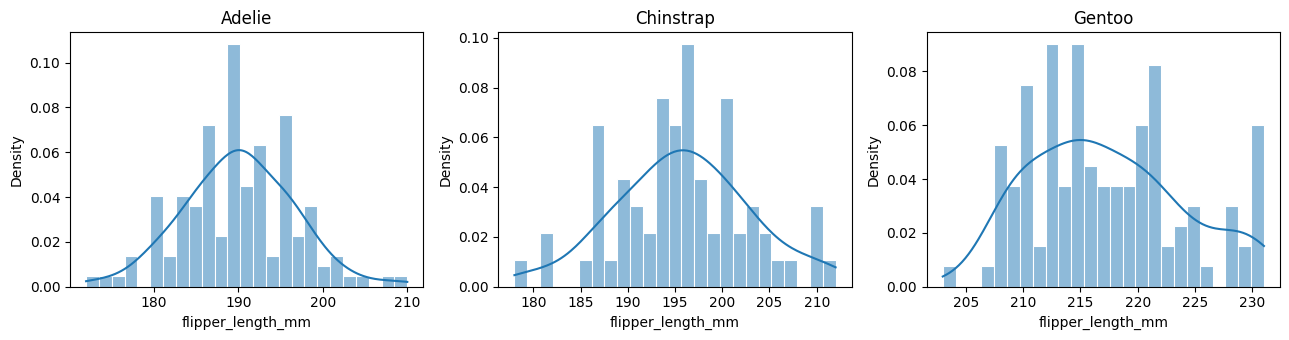

In [8]:
fig, axes = plt.subplots(1, 3, figsize = (13, 3.5))

for ax, (species, group) in zip(axes, df.groupby('species')):
    ax.set_title(species)
    values = group['flipper_length_mm']
    sns.histplot(values, bins=25, stat="density", kde=True, alpha=0.5, edgecolor="white", ax=ax)

plt.tight_layout()
plt.show()



### Задание 2

Выполним тест Шапиро — Уилка для `flipper_length_mm`.

In [9]:
result = stats.shapiro(flipper)
result

ShapiroResult(statistic=np.float64(0.951705230756506), pvalue=np.float64(5.393184873708796e-09))

Принимаем или отвергаем мы нулевую гипотезу? Какой это позволяет сделать вывод о нормальности распределения?

In [10]:
print(type(result)),
print(f"W = {result.statistic:.3f}, p-value = {result.pvalue:.3g}")

<class 'scipy.stats._morestats.ShapiroResult'>
W = 0.952, p-value = 5.39e-09


Повторите для `flipper_length_mm` отдельно для каждого вида. Оформите результат через `pd.DataFrame`.

In [11]:
result = []

for species, group in df.groupby('species'):
  values = group['flipper_length_mm']

  test_res = stats.shapiro(values)

  result.append({
      'species': species,
      'statistic': test_res.statistic,
      'p-value': test_res.pvalue,
  })
pd.DataFrame(result)

,species,statistic,p-value
0,Adelie,0.993405,0.742743
1,Chinstrap,0.988911,0.810645
2,Gentoo,0.961477,0.001760


#### Задание 3

Построим нормальный Q–Q plot для `flipper_length_mm`.

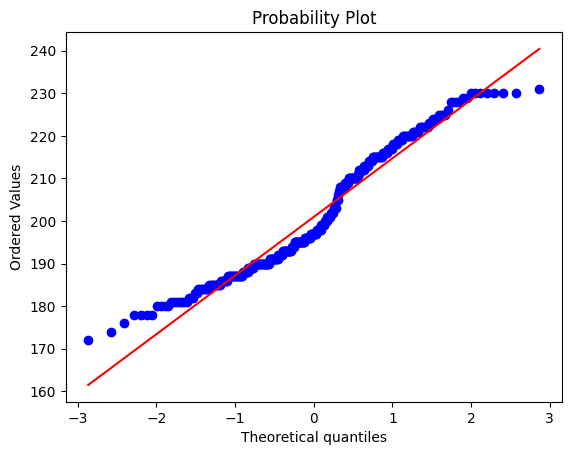

In [12]:
stats.probplot(flipper, dist="norm", plot=plt)
plt.show()

Повторите для тех же групп и изобразите на сетке 1 × 3.

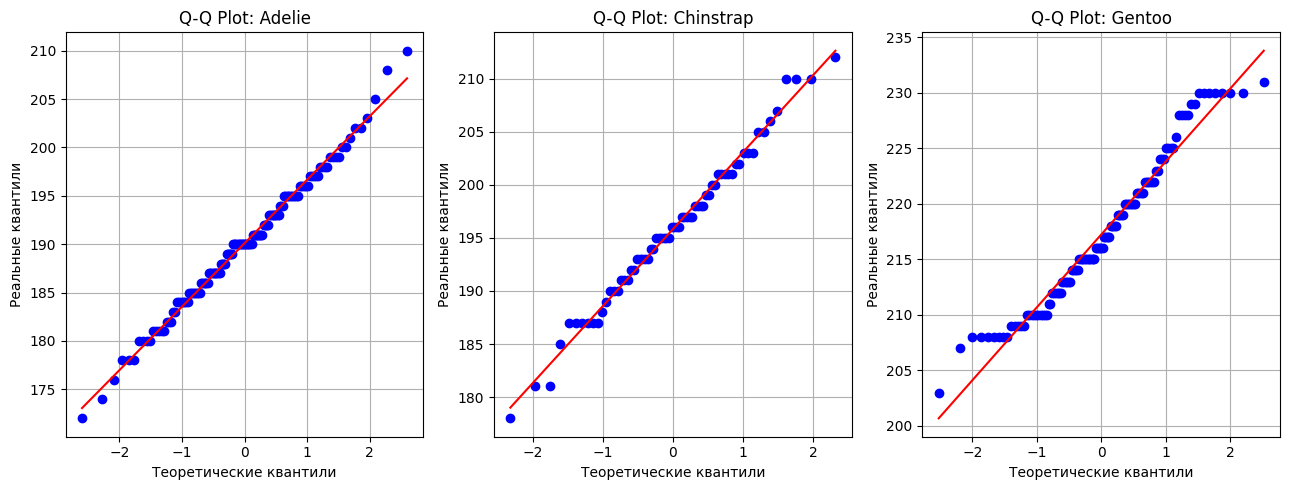

In [13]:
fig, axes = plt.subplots(1, 3, figsize = (13, 5))

for ax, (species, group) in zip(axes, df.groupby('species')):
    values = group['flipper_length_mm']

    stats.probplot(values, dist="norm", plot=ax)
    ax.set_title(f"Q-Q Plot: {species}")
    ax.set_xlabel("Теоретические квантили")
    ax.set_ylabel("Реальные квантили")
    ax.grid(True)

plt.tight_layout()
plt.show()

### Задание 4

Выполним тест Колмогорова — Смирнова для все той же переменной. Для этого понадобится подставить среднее и стандартное отклонения выборки.

In [14]:
result = stats.kstest(flipper, lambda x: stats.norm.cdf(x, loc=flipper.mean(), scale=flipper.std()))
f"D = {result.statistic:.3f}, p-value = {result.pvalue:.3g}"

'D = 0.125, p-value = 5.46e-05'

Обычный тест Колмогорова — Смирнова предполагает, что параметры проверяемого распределения заданы априори. Если мы оцениваем их по той же выборке, стандартное p-value оказывается некорректно. Для проверки нормальности с эмпирически оцененными средним и дисперсией лучше использовать модификацию Лиллиефорса. Ее реализация есть в библиотеке `statsmodels`.

In [15]:
from statsmodels.stats.diagnostic import lilliefors

lilliefors(flipper, dist="norm")

(np.float64(0.12493891561210568), np.float64(0.0009999999999998899))

Повторите тест Лиллиефорса для длин ласт всех трех видов. Запишите результаты в датафрейм.

In [16]:
lilliefors_results = []

for species, group in df.groupby("species"):
    values = group["flipper_length_mm"]
    statistic, p_value = lilliefors(values, dist="norm")
    lilliefors_results.append(
        {"species": species, "statistic": statistic, "p-value": p_value}
    )
df_lilliefors = pd.DataFrame(lilliefors_results)
df_lilliefors

,species,statistic,p-value
0,Adelie,0.069058,0.129027
1,Chinstrap,0.056977,0.883767
2,Gentoo,0.095042,0.015913
